# Diffusion Transformer as High-Energy Physics Surrogate



The objective of this tutorial is to introduce the fundamental concepts behind modern generative models, with a particular focus on Denoising Diffusion Probabilistic Models (DDPMs), and to demonstrate how these models can be applied to simulation and reconstruction problems in High Energy Physics. By the end of the tutorial, participants will understand the diffusion process, train a simple DDPM implementation in Python, and gain practical insight into adapting diffusion models for calorimeter shower generation and related HEP applications.

In [ ]:
import os
import sys

REPO = "https://github.com/X-T-Nguyen/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School.git"

if not os.path.exists("/content/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School"):
    !git clone $REPO

sys.path.insert(
    0,
    "/content/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School"
)

In [61]:
from IPython.display import Image

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms
from torchvision.utils import save_image

import time
import math
import random
import os
from collections import OrderedDict
from copy import deepcopy

from timm.models.vision_transformer import PatchEmbed, Attention, Mlp

from diffusion import create_diffusion

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

False
CPU


## Overview

### Methodology


![Alt Text](Images/ddpm_scheme.png)

### Studying Case: Fast Calorimeter Simulation Challenge 2022 (Dataset 2)

Image![Alt Text](Images/Calo.png)

The **Fast Calorimeter Simulation Challenge 2022 (CaloChallenge) Dataset 2**
consists of simulated electron showers in a cylindrical calorimeter.

The dataset contains:

- **100,000 training showers** and **100,000 reference showers**
- Electron incident energies sampled **log-uniformly from 1 GeV to 1 TeV**
- A calorimeter with **45 layers** along the depth direction
- **9 radial bins** and **16 angular bins** per layer
- A total of

$$
45 \times 9 \times 16 = 6480
$$

calorimeter cells (voxels) per shower.

The shower data can therefore be represented as a four-dimensional array,

$$
\mathrm{shower} \in
\mathbb{R}^{N \times 45 \times 16 \times 9},
$$

where $N$ is the number of showers, and the three spatial dimensions
correspond to **depth (layer)**, **azimuthal angle**, and **radial position**.

Each voxel contains the deposited energy in that calorimeter cell. The
training dataset is provided as `dataset_2_1.hdf5`, while `dataset_2_2.hdf5`
provides an independent reference sample for evaluation.

In this notebook, the showers are visualized in two complementary ways:
a **longitudinal view** showing the shower development with depth, and a
**transverse view** showing the energy distribution in the plane
perpendicular to the shower axis.

## Data Preparation

#### Reduced dataset for the tutorial

The original CaloChallenge Dataset 2 is large, which is not ideal for an
interactive tutorial. To keep the analysis lightweight and manageable, we
use a reduced subset of **10,000 showers**.

The reduced dataset contains the same shower representation and calorimeter
geometry as the original dataset, but with fewer events:

$$
N_{\mathrm{showers}} = 10\,000.
$$

This allows us to explore the data and visualize the shower distributions
without requiring the full dataset.

--------------------------------------------

Install data from Zenodo

In [9]:
!wget -O dataset_2_1_10k.hdf5 \
"https://zenodo.org/records/22640769/files/dataset_2_1_10k.hdf5?download=1"

--2026-09-07 12:08:47--  https://zenodo.org/records/22640769/files/dataset_2_1_10k.hdf5?download=1
Resolving zenodo.org (zenodo.org)... 2001:1458:d00:3b::100:4d6, 2001:1458:d00:17::100:1d9, 2001:1458:d00:13::100:f2, ...
Connecting to zenodo.org (zenodo.org)|2001:1458:d00:3b::100:4d6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134219567 (128M) [application/octet-stream]
Saving to: ‘dataset_2_1_10k.hdf5’

dataset_2_1_10k.hdf 100%[===================>] 128.00M  7.04MB/s    in 19s     

2026-09-07 12:09:06 (6.67 MB/s) - ‘dataset_2_1_10k.hdf5’ saved [134219567/134219567]



In case Zenodo is not working

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1rqmMuCRMVJGt6yM9slRw2Ia7WCn8lrM7/view?usp=share_link" \
    -O dataset_2_1_10k.hdf5

#### Plot parameters and radial mirroring

The plot uses `45` layers, `12` angular bins, and `12` radial bins:

$$
N_{\mathrm{layers}} = 45, \qquad
N_{\alpha} = 12, \qquad
N_R = 12
$$

For visualization, the radial coordinate is mirrored around the shower core.

If $I_r$ denotes the image value at radial bin $r$, the displayed image is:

$$
I_{\mathrm{plot}} =
\begin{bmatrix}
I_{N_R-1} \\
\vdots \\
I_2 \\
I_1 \\
I_0 \\
I_1 \\
I_2 \\
\vdots \\
I_{N_R-1}
\end{bmatrix}
$$

where $I_0$ is the shower core.

This mirroring is only a visualization step: it does not introduce any new information.

In [ ]:
LAYERS, N_ALPHA, N_R = 45, 12, 12   

def _mirror_radial(img_r_first):
    """Moves radial bin 0 (shower core) to the middle row and mirrors
    outward, purely for a nicer plot (no new information added)."""
    return np.concatenate([img_r_first[:0:-1], img_r_first], axis=0)

#### Longitudinal shower view

For each shower, the energy is summed over the angular bins to obtain a
2D representation in **depth (layer)** and **radius**:

$$
I_{\ell,r} = \sum_{\alpha} I_{\ell,\alpha,r},
$$

where $\ell$ denotes the layer (depth), $\alpha$ the angular bin, and $r$
the radial bin.

The radial profile is then mirrored around the shower core ($r=0$) for
visualization:

$$
I_{\ell,r}
\;\longrightarrow\;
\left[
I_{\ell,n_r-1},\ldots,I_{\ell,1},
I_{\ell,0},
I_{\ell,1},\ldots,I_{\ell,n_r-1}
\right].
$$

Thus, the resulting image shows the **longitudinal development of the
shower as a function of depth and radial distance from the core**.

The color scale is logarithmic and represents deposited energy in MeV.

In [ ]:
def plot_longitudinal(showers, energies_mev, n_show=5):
    """showers: (N, layers, n_alpha, n_r). Longitudinal (depth vs radius) view,
    summed over the angular axis."""
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2), squeeze=False)

    for i in range(n_show):
        img = showers[i].sum(axis=1)  # (layers, n_r) - summed over angular bins
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        n_r = img.shape[1]

        img_mirrored = _mirror_radial(img.T)  # (2*n_r-1, layers), core row centered
        vmax = img_mirrored.max() if img_mirrored.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        im = ax.imshow(
            img_mirrored + 1e-3,
            norm=LogNorm(vmin=1e-2, vmax=vmax),
            aspect="auto", origin="lower", cmap="inferno",
        )
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV")
        ax.set_xlabel("layer (depth)")
        if i == 0:
            ax.set_ylabel("radial bin")
        ax.set_yticks([0, n_r - 1, 2 * n_r - 2])
        ax.set_yticklabels([f"-{n_r - 1}", "0", f"{n_r - 1}"])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MeV")

    plt.tight_layout()
    plt.show()

#### Transverse shower view

For each shower, the energy is summed over all layers (depth) to obtain a
2D representation in **azimuthal angle** and **radial distance**:

$$
I_{\alpha,r} = \sum_{\ell} I_{\ell,\alpha,r},
$$

where $\ell$ denotes the layer (depth), $\alpha$ the angular bin, and $r$
the radial bin.

The resulting transverse energy distribution is displayed in polar
coordinates, with

$$
\alpha \in [0,2\pi],
\qquad
r \in [0,1].
$$

Here, the radial coordinate is **normalized for visualization only**.
The actual radial bins are non-uniform, so this representation is intended
to show the overall transverse shower shape rather than the exact physical
radial scale.

The color scale is logarithmic and represents deposited energy in MeV.

In [62]:
def plot_transverse(showers, energies_mev, n_show=5):
    """showers: (N, layers, n_alpha, n_r). Head-on polar view, summed over depth."""
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2),
                              subplot_kw={"projection": "polar"}, squeeze=False)

    n_alpha, n_r = showers.shape[2], showers.shape[3]
    theta_edges = np.linspace(0, 2 * np.pi, n_alpha + 1)
    r_edges = np.linspace(0, 1, n_r + 1)  # normalized bins - real bins are non-uniform, this is just for eyeballing shape
    Theta, R = np.meshgrid(theta_edges, r_edges)

    for i in range(n_show):
        img = showers[i].sum(axis=0)  # (n_alpha, n_r)
        vals = np.nan_to_num(img.T, nan=0.0, posinf=0.0, neginf=0.0)
        vmax = vals.max() if vals.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        mesh = ax.pcolormesh(Theta, R, vals + 1e-3,
                              norm=LogNorm(vmin=1e-2, vmax=vmax),
                              cmap="inferno", shading="auto")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV", fontsize=10)
        ax.set_yticklabels([])
        plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.1, label="MeV")

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot the image




#### Data Preprocession

In [ ]:
class CaloChallengeDataset(Dataset):

    def __init__(self, h5_path):
        self.h5_path = h5_path

        # Load the two datasets from the HDF5 file
        with h5py.File(h5_path, "r") as f:
            self.energies = ...
            self.showers = ...

    def __len__(self):
        ...

    def __getitem__(self, idx):

        # Dataset 2: 45 × 16 × 9
        shower = ...

        # Preprocessing
        shower = ...
        shower = ...

        # Energy conditioning
        e_inc = ...
        e_cond = ...

        # Convert to tensors
        shower = ...
        e_cond = ...

        return shower, e_cond

## Transformer Design

![Alt Text](Images/scheme.png)

In [20]:
def modulate(x, shift, scale): # Adaptive Layer Normalization modulation
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

In [ ]:
#################################################################################
# Timestep Embedding
#################################################################################

class TimestepEmbedder(nn.Module):

    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()

        # TODO: Build an MLP
        self.mlp = nn.Sequential(
            ...
        )

        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):

        half = dim // 2

        # TODO
        freqs = ...

        # TODO
        args = ...

        # TODO
        embedding = ...

        if dim % 2:
            # TODO: Add one zero dimension
            embedding = ...

        return embedding

    def forward(self, t):

        # TODO
        t_freq = ...

        return self.mlp(t_freq)

In [ ]:
#################################################################################
# Energy Conditioning (continuous, log10(E))
#################################################################################

class EnergyEmbedder(nn.Module):

    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()

        # TODO: Build the MLP
        self.mlp = nn.Sequential(
            ...
        )

        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def sinusoidal_embedding(e, dim, max_period=10000):

        # TODO
        half = ...

        # TODO: Create frequencies
        freqs = ...

        # TODO: Combine energy and frequencies
        args = ...

        # TODO: Create sinusoidal embedding
        emb = ...

        # Handle odd dimensions
        if dim % 2:
            # TODO
            emb = ...

        return emb

    def forward(self, e_cond):

        # TODO: Create sinusoidal energy embedding
        e_freq = ...

        # TODO: Project to hidden size
        return ...

In [25]:
#################################################################################
# Config Conditioning — tells the model which geometry (ds2)
#################################################################################
class ConfigEmbedder(nn.Module):
    def __init__(self, hidden_size, num_configs):
        super().__init__()
        self.embed = nn.Embedding(num_configs, hidden_size)

    def forward(self, config_idx):
        # config_idx: LongTensor (B,) of config indices
        return self.embed(config_idx)

In [26]:
#################################################################################
# DiT Block
#################################################################################

class DiTBlock(nn.Module):

    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0):
        super().__init__()

        # TODO: Layer normalization before attention
        self.norm1 = ...

        # TODO: Multi-head self-attention
        self.attn = ...

        # TODO: Layer normalization before MLP
        self.norm2 = ...

        # MLP
        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        approx_gelu = lambda: nn.GELU(approximate="tanh")

        self.mlp = Mlp(
            in_features=hidden_size,
            hidden_features=mlp_hidden_dim,
            act_layer=approx_gelu,
            drop=0
        )

        # TODO: AdaLN modulation
        # Produces 6 values per hidden dimension:
        # shift, scale, gate for attention
        # shift, scale, gate for MLP
        self.adaLN_modulation = nn.Sequential(
            ...
        )

    def forward(self, x, c):

        # TODO: Generate AdaLN parameters
        shift_msa, scale_msa, gate_msa, \
        shift_mlp, scale_mlp, gate_mlp = ...

        # TODO: Normalize and modulate before attention
        mod_tokens = ...

        # Attention
        B, N, C = mod_tokens.shape

        # TODO: Create Q, K, V
        qkv = ...

        # TODO: Reshape into heads
        qkv = ...

        # TODO: Rearrange dimensions
        qkv = ...

        q, k, v = qkv[0], qkv[1], qkv[2]

        # TODO: Scaled dot-product attention
        attn = ...

        attn = attn.softmax(dim=-1)

        # TODO: Apply attention to V
        attn_out = ...

        # TODO: Put heads back together
        attn_out = ...

        # TODO: Final attention projection
        attn_out = ...

        # Residual connection + attention gate
        x = ...

        # TODO: MLP branch
        x = ...

        return x

In [27]:
#################################################################################
# Final Layer
#################################################################################

class FinalLayer(nn.Module):

    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()

        # TODO: Final normalization
        self.norm_final = ...

        # TODO: Project each token back to patch values
        self.linear = ...

        # TODO: AdaLN modulation
        # We need shift and scale
        self.adaLN_modulation = nn.Sequential(
            ...
        )

    def forward(self, x, c):

        # TODO: Get shift and scale from conditioning
        shift, scale = ...

        # TODO: Normalize and modulate
        x = ...

        # TODO: Project to output patch
        x = ...

        return x

#### DiT model

The **Diffusion Transformer (DiT)** is the main neural network used to model
and generate calorimeter showers.

The input shower is represented as a 2D image with the calorimeter layers
treated as channels:

$$
x \in \mathbb{R}^{B\times45\times H\times W},
$$

where $B$ is the batch size and the spatial dimensions $(H,W)$ describe the
calorimeter geometry.

The model first divides the calorimeter into small patches and converts each
patch into a Transformer token. For the Dataset 2 geometry used here, the
padded input has size $16\times10$ and we use $2\times2$ patches:

$$
(45,16,10)
\rightarrow
(384,8,5)
\rightarrow
(40,384).
$$

Thus, each shower is represented by **40 tokens**, each with a hidden
dimension of $384$.

The Transformer then processes these tokens using several sources of
information:

1. **Patch embedding**  
   A convolution converts each calorimeter patch into a hidden
   representation.

2. **Positional embeddings**  
   Fixed 2D sinusoidal embeddings tell the Transformer where each patch is
   located. The angular coordinate uses a circular encoding, while the radial
   coordinate uses a linear encoding.

3. **Diffusion timestep**  
   The timestep $t$ tells the model where the current sample is in the
   diffusion process.

4. **Incident energy**  
   The incident particle energy $E_{\mathrm{inc}}$ provides the physical
   conditioning for the generated shower. Here the model uses
   $\log_{10}(E_{\mathrm{inc}})$ as input to the energy embedding.

5. **Configuration embedding**  
   The model also receives an embedding identifying the detector
   configuration. This allows the same architecture to support multiple
   calorimeter geometries.

The three conditioning embeddings are combined into a single conditioning
vector:

$$
c =
c_t + c_E + c_{\mathrm{config}}.
$$

This vector is supplied to every Transformer block.

The overall architecture can therefore be summarized as

$$
\boxed{
\text{calorimeter}
\rightarrow
\text{patch embedding}
\rightarrow
\text{positional embedding}
\rightarrow
\text{Transformer blocks}
\rightarrow
\text{FinalLayer}
\rightarrow
\text{calorimeter}
}
$$

The **FinalLayer** converts the processed Transformer tokens back into
patch values, and `unpatchify` rearranges these patches into the original
calorimeter image layout.

With `learn_sigma=True`, the model predicts twice the number of input
channels:

$$
C_{\mathrm{out}} = 2C_{\mathrm{in}} = 90.
$$

The two sets of channels are used by the diffusion model for its output and
variance-related prediction.

The model used here has:

$$
\text{hidden size}=384,\qquad
\text{depth}=12,\qquad
\text{heads}=6,
$$

with a patch size of $2\times2$.

The weight initialization is included in the implementation below, but is
not essential for understanding the overall architecture.

In [28]:
#################################################################################
# DiT Model — multi-config version
#################################################################################

# geometry per config, already padded to be patch_size(=2)-divisible
CALO_CONFIGS = {
    "dataset2": dict(input_size=(16, 10), n_r_real=9),   # radial padded 9->10
}

class DiT(nn.Module):
    def __init__(
        self,
        configs=CALO_CONFIGS,
        patch_size=2,
        in_channels=45,          
        hidden_size=384,
        depth=12,
        num_heads=6,
        mlp_ratio=4.0,
        learn_sigma=True,
    ):
        super().__init__()

        self.configs = configs
        self.config_names = list(configs.keys())
        self.config_to_idx = {name: i for i, name in enumerate(self.config_names)}

        self.learn_sigma = learn_sigma
        self.in_channels = in_channels
        self.out_channels = in_channels * 2 if learn_sigma else in_channels
        self.patch_size = patch_size
        self.hidden_size = hidden_size

        # SHARED patch embedding conv (plain Conv2d instead of timm's PatchEmbed,
        # so it isn't locked to one fixed img_size - same weights work for any
        # (H, W) as long as in_channels/patch_size match, which they do here)
        self.patch_conv = nn.Conv2d(
            in_channels, hidden_size,
            kernel_size=patch_size, stride=patch_size, bias=True
        )

        self.t_embedder = TimestepEmbedder(hidden_size)
        self.cond_embedder = EnergyEmbedder(hidden_size)
        self.config_embedder = ConfigEmbedder(hidden_size, num_configs=len(configs))

        # per-config positional embeddings + grid sizes (registered as buffers,
        # not learnable - same as the original DiT's fixed sincos embedding)
        self.grid_sizes = {}
        for name, cfg in configs.items():
            H, W = cfg["input_size"]
            h_p, w_p = H // patch_size, W // patch_size
            self.grid_sizes[name] = (h_p, w_p)

            pe = get_2d_sincos_pos_embed(hidden_size, (h_p, w_p))
            self.register_buffer(
                f"pos_embed_{name}",
                torch.from_numpy(pe).float().unsqueeze(0)
            )

        self.blocks = nn.ModuleList([
            DiTBlock(hidden_size, num_heads, mlp_ratio=mlp_ratio)
            for _ in range(depth)
        ])

        self.final_layer = FinalLayer(hidden_size, patch_size, self.out_channels)

        self.initialize_weights()

    def initialize_weights(self):
        def _basic_init(module):
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
        self.apply(_basic_init)

        w = self.patch_conv.weight.data
        nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        nn.init.constant_(self.patch_conv.bias, 0)

        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)
        nn.init.normal_(self.cond_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.cond_embedder.mlp[2].weight, std=0.02)
        nn.init.normal_(self.config_embedder.embed.weight, std=0.02)

        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)

        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)

    def unpatchify(self, x, config_name):
        c = self.out_channels
        p = self.patch_size
        h_p, w_p = self.grid_sizes[config_name]

        x = x.reshape(shape=(x.shape[0], h_p, w_p, p, p, c))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], c, h_p * p, w_p * p))
        return imgs

    def forward(self, x, t, e_cond, config_name):
        """
        x: (B, 45, H, W) image for the given config_name
        t: (B,) diffusion timesteps
        e_cond: (B,) log10(incident energy)
        config_name: str, one of self.config_names - the WHOLE batch must be
                     the same config (different configs can't share a tensor
                     shape). See train_upscale.py for how to interleave
                     batches across configs during training.
        """
        assert config_name in self.configs, f"unknown config {config_name}"

        pos_embed = getattr(self, f"pos_embed_{config_name}")

        tokens = self.patch_conv(x)                      # (B, hidden, h_p, w_p)
        tokens = tokens.flatten(2).transpose(1, 2)        # (B, N, hidden)
        tokens = tokens + pos_embed

        t_emb = self.t_embedder(t)
        e_emb = self.cond_embedder(e_cond)

        config_idx = torch.full(
            (x.shape[0],), self.config_to_idx[config_name],
            dtype=torch.long, device=x.device
        )
        cfg_emb = self.config_embedder(config_idx)

        c = t_emb + e_emb + cfg_emb

        for block in self.blocks:
            tokens = block(tokens, c)

        tokens = self.final_layer(tokens, c)
        x_out = self.unpatchify(tokens, config_name)
        return x_out

#### Positional embeddings

After dividing the calorimeter into patches, each patch is represented by a
token that is processed by the Transformer.

However, a Transformer does not inherently know where each token came from.
We therefore add a **positional embedding** to each token to provide
information about its location in the calorimeter:

$$
\text{token} =
\text{patch representation}
+
\text{positional embedding}.
$$

For our calorimeter, the spatial coordinates have different meanings:

- **Radial direction:** a linear coordinate, so we use a standard sinusoidal
  positional encoding.
- **Angular direction:** a periodic coordinate, so we use a circular
  sinusoidal encoding.

The angular coordinate should wrap around naturally:

$$
\alpha = 0
\quad\text{and}\quad
\alpha = 2\pi
$$

represent the same direction. The circular encoding accounts for this
periodicity.

The function below constructs a 2D positional embedding by combining these
two 1D encodings. For an $8\times5$ patch grid, it produces

$$
8\times5 = 40
$$

positional embeddings, one for each Transformer token.

In [29]:
#################################################################################
# Positional Embeddings (rectangular, angular axis circular)
#################################################################################

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h, grid_w = grid_size
    emb_h = get_1d_sincos_pos_embed_circular(embed_dim // 2, grid_h)
    emb_w = get_1d_sincos_pos_embed_linear(embed_dim // 2, grid_w)

    emb_h_grid = np.repeat(emb_h[:, None, :], grid_w, axis=1)
    emb_w_grid = np.repeat(emb_w[None, :, :], grid_h, axis=0)

    emb = np.concatenate([emb_h_grid, emb_w_grid], axis=-1)
    return emb.reshape(grid_h * grid_w, embed_dim)


def get_1d_sincos_pos_embed_circular(embed_dim, n_positions):
    k = np.arange(1, embed_dim // 2 + 1, dtype=np.float64)
    pos = np.arange(n_positions, dtype=np.float64)
    angle = 2 * np.pi * np.outer(pos, k) / n_positions
    emb_sin = np.sin(angle)
    emb_cos = np.cos(angle)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    if emb.shape[1] < embed_dim:
        emb = np.concatenate([emb, np.zeros((n_positions, embed_dim - emb.shape[1]))], axis=1)
    return emb


def get_1d_sincos_pos_embed_linear(embed_dim, n_positions):
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000 ** omega
    pos = np.arange(n_positions, dtype=np.float64)
    out = np.einsum('m,d->md', pos, omega)
    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    return emb

## Model Training

In [30]:
# Reproducibility
seed = 1234567890
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [57]:
# Paths / settings
SAVE_DIR = "./checkpoints/"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = ...
EPOCHS = ...
LR = ...
NUM_WORKERS = 1

In [1]:
# Check dataset

dataset = CaloChallengeDataset(H5_PATH)

print("Number of samples:", len(dataset))

x, energy = dataset[0]

print("Shower shape:", x.shape)
print("Conditioning energy:", energy.item())

In [40]:
# Loader

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

x_batch, e_batch = next(iter(loader))
print("Batch image shape:", x_batch.shape)
print("Batch energy shape:", e_batch.shape)

Batch image shape: torch.Size([32, 45, 16, 10])
Batch energy shape: torch.Size([32])


In [50]:
model = DiT(configs=CALO_CONFIGS).to(device)

ema = deepcopy(model).to(device)

diffusion = create_diffusion(timestep_respacing="")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0
)

print("Model and diffusion are ready.")

Model and diffusion are ready.


In [51]:
@torch.no_grad()
def update_ema(ema_model, model, decay=0.9999):

    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())

    for name, param in model_params.items():
        ema_params[name].mul_(decay).add_(
            param.data,
            alpha=1 - decay
        )

In [58]:
model.train()
for epoch in range(EPOCHS):
    t0 = time.time()
    running_loss = 0.0
    for step, (x, e_cond) in enumerate(loader):
        x = x.to(device)
        e_cond = e_cond.to(device)

        t = torch.randint(0, diffusion.num_timesteps, (x.shape[0],), device=device)

        model_kwargs = {"e_cond": e_cond, "config_name": "dataset2"}

        loss_dict = diffusion.training_losses(model, x, t, model_kwargs)
        loss = loss_dict["loss"].mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_ema(ema, model)
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    dt = time.time() - t0
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.6f} | Time: {dt:.2f} sec")

    # Save checkpoint
    os.makedirs(SAVE_DIR, exist_ok=True)
    CKPT_PATH = os.path.join(SAVE_DIR, "latest.pt")
    checkpoint = {
        "model": model.state_dict(),
        "ema": ema.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch + 1
    }
    torch.save(checkpoint, CKPT_PATH)
    print(f"Saved: {CKPT_PATH}")

Epoch [1/2] | Loss: 0.176674 | Time: 167.98 sec
Saved: ./checkpoints/latest.pt
Epoch [2/2] | Loss: 0.177029 | Time: 187.70 sec
Saved: ./checkpoints/latest.pt


In [ ]:
# Installing checkpoint from Zenodo

!wget -O checkpoints/latest.pt \
"https://zenodo.org/records/22658456/files/latest.pt?download=1"

In [ ]:
# Installing checkpoint from Google drive

!gdown --fuzzy "https://drive.google.com/file/d/1X8Q-iXbv3I9lQiT1X0_EO04OOTnLKwWs/view?usp=share_link" \
    -O checkpoints/latest.pt

## Sampling the results

In [63]:
CONFIG_NAME = "dataset2"          
CKPT_PATH = os.path.join(SAVE_DIR, "latest.pt")  
USE_EMA = True

VOXEL_THRESHOLD_MEV = 0.015       
N_R_REAL = CALO_CONFIGS[CONFIG_NAME]["n_r_real"]  

In [64]:
def load_model(checkpoint_path, device, use_ema=True):
    model = DiT(configs=CALO_CONFIGS).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["ema"] if use_ema else ckpt["model"]
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Loaded {'EMA' if use_ema else 'raw'} weights from {checkpoint_path} "
          f"(epoch {ckpt.get('epoch', '?')})")
    return model

sampling_model = load_model(CKPT_PATH, device, use_ema=USE_EMA)

Loaded EMA weights from ./checkpoints/latest.pt (epoch 2)


In [65]:
@torch.no_grad()
def sample_showers(model, config_name, energies_mev, device, apply_threshold=True):
    N = len(energies_mev)
    e_cond = torch.tensor([math.log10(e) for e in energies_mev], dtype=torch.float32).to(device)

    sample_diffusion = create_diffusion(timestep_respacing="ddim100")

    cfg = CALO_CONFIGS[config_name]
    shape = (N, 45, *cfg["input_size"])
    noise = torch.randn(*shape, device=device)

    model_kwargs = dict(e_cond=e_cond, config_name=config_name)

    samples = sample_diffusion.ddim_sample_loop(
        model, shape, noise=noise, clip_denoised=False,
        model_kwargs=model_kwargs, progress=True, device=device,
    )
    samples = samples.cpu().numpy()

    samples = np.clip(samples, -20, 20)     # keep expm1 finite for undertrained checkpoints
    samples = np.expm1(samples)             # invert log1p compression
    samples = np.clip(samples, 0, None)     # clip tiny negative diffusion noise

    if apply_threshold:
        samples[samples < VOXEL_THRESHOLD_MEV] = 0.0

    samples = samples[:, :, :, :cfg["n_r_real"]]   # strip radial padding
    return samples   # (N, 45, H, n_r_real) in MeV

In [66]:
energies_gev = [1, 10, 100, 500, 1000]
energies_mev = [e * 1000.0 for e in energies_gev]

generated = sample_showers(sampling_model, CONFIG_NAME, energies_mev, device, apply_threshold=True)

print("Generated shape:", generated.shape)
for i, e in enumerate(energies_mev):
    print(f"  sample {i}: E_inc={e:.0f} MeV | E_dep={generated[i].sum():.0f} MeV | "
          f"nonzero voxels={np.count_nonzero(generated[i])}")

  0%|          | 0/100 [00:00<?, ?it/s]

Generated shape: (5, 45, 16, 9)
  sample 0: E_inc=1000 MeV | E_dep=1420365135872 MeV | nonzero voxels=3265
  sample 1: E_inc=10000 MeV | E_dep=1408069664768 MeV | nonzero voxels=3271
  sample 2: E_inc=100000 MeV | E_dep=1425479958528 MeV | nonzero voxels=3292
  sample 3: E_inc=500000 MeV | E_dep=1396858945536 MeV | nonzero voxels=3223
  sample 4: E_inc=1000000 MeV | E_dep=1405340221440 MeV | nonzero voxels=3233


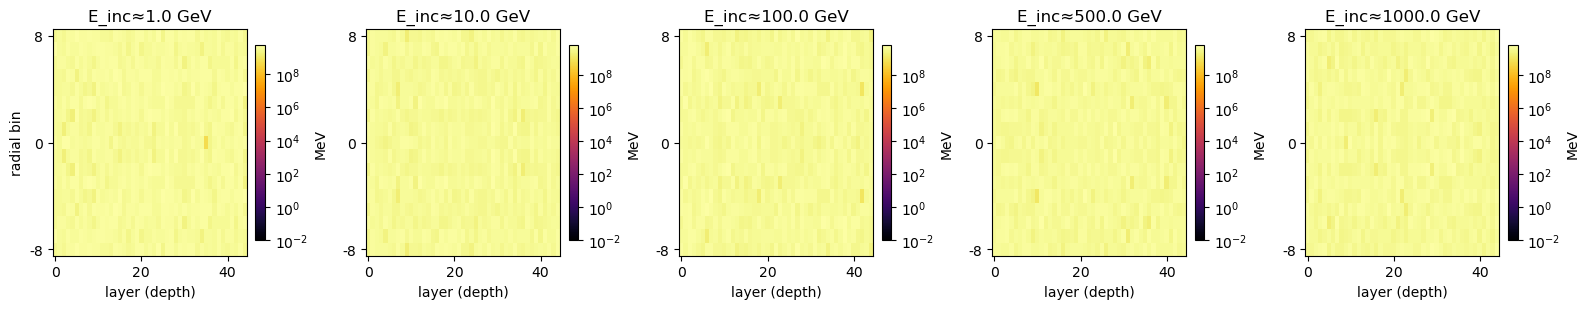

In [67]:
def _mirror_radial(img_r_first):
    return np.concatenate([img_r_first[:0:-1], img_r_first], axis=0)

def plot_longitudinal(showers, energies_mev, n_show=5):
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2), squeeze=False)
    for i in range(n_show):
        img = np.nan_to_num(showers[i].sum(axis=1), nan=0.0, posinf=0.0, neginf=0.0)
        n_r = img.shape[1]
        img_mirrored = _mirror_radial(img.T)
        vmax = img_mirrored.max() if img_mirrored.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        im = ax.imshow(img_mirrored + 1e-3, norm=LogNorm(vmin=1e-2, vmax=vmax),
                        aspect="auto", origin="lower", cmap="inferno")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV")
        ax.set_xlabel("layer (depth)")
        if i == 0:
            ax.set_ylabel("radial bin")
        ax.set_yticks([0, n_r - 1, 2 * n_r - 2])
        ax.set_yticklabels([f"-{n_r-1}", "0", f"{n_r-1}"])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MeV")
    plt.tight_layout()
    plt.show()

plot_longitudinal(generated, energies_mev)

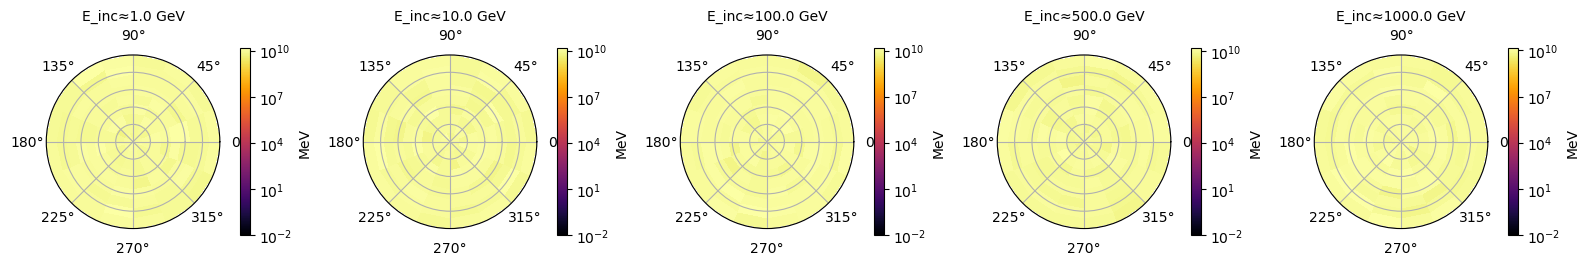

In [68]:
def plot_transverse(showers, energies_mev, n_show=5):
    n_show = min(n_show, len(showers))
    n_alpha, n_r = showers.shape[2], showers.shape[3]
    theta_edges = np.linspace(0, 2 * np.pi, n_alpha + 1)
    r_edges = np.linspace(0, 1, n_r + 1)
    Theta, R = np.meshgrid(theta_edges, r_edges)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2),
                              subplot_kw={"projection": "polar"}, squeeze=False)
    for i in range(n_show):
        vals = np.nan_to_num(showers[i].sum(axis=0).T, nan=0.0, posinf=0.0, neginf=0.0)
        vmax = vals.max() if vals.max() > 1e-2 else 1e-1
        ax = axes[0][i]
        mesh = ax.pcolormesh(Theta, R, vals + 1e-3, norm=LogNorm(vmin=1e-2, vmax=vmax),
                              cmap="inferno", shading="auto")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV", fontsize=10)
        ax.set_yticklabels([])
        plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.1, label="MeV")
    plt.tight_layout()
    plt.show()

plot_transverse(generated, energies_mev)

## Performance Evaluation

In [73]:
CONFIG_NAME = "dataset2"
REAL_H5_PATH = H5_PATH          
NUM_EVAL_SAMPLES = 50          
GEN_BATCH_SIZE = 64

VOXEL_THRESHOLD_MEV = {"dataset2": 0.01515}
LOG1P_CLIP_MAX = {"dataset2": 9.62, "dataset3": 9.26}
LOG1P_CLIP_MIN = -20.0

In [74]:
def _make_clamp_fn(clip_min, clip_max):
    def denoised_fn(x0_pred):
        return torch.clamp(x0_pred, clip_min, clip_max)
    return denoised_fn

@torch.no_grad()
def generate_batched(model, config_name, energies_mev, device, gen_batch_size=64,
                      timestep_respacing="ddim500", apply_threshold=True):
    cfg = CALO_CONFIGS[config_name]
    n_r_real = cfg["n_r_real"]
    gen_diffusion = create_diffusion(timestep_respacing=timestep_respacing)
    clamp_fn = _make_clamp_fn(LOG1P_CLIP_MIN, LOG1P_CLIP_MAX[config_name])

    all_samples = []
    N = len(energies_mev)
    for start in range(0, N, gen_batch_size):
        chunk = energies_mev[start:start + gen_batch_size]
        e_cond = torch.tensor([math.log10(e) for e in chunk], dtype=torch.float32).to(device)
        shape = (len(chunk), 45, *cfg["input_size"])
        noise = torch.randn(*shape, device=device)
        model_kwargs = dict(e_cond=e_cond, config_name=config_name)

        samples = gen_diffusion.ddim_sample_loop(
            model, shape, noise=noise, clip_denoised=False, denoised_fn=clamp_fn,
            model_kwargs=model_kwargs, progress=False, device=device,
        )
        samples = samples.cpu().numpy()
        samples = np.clip(samples, LOG1P_CLIP_MIN, LOG1P_CLIP_MAX[config_name])
        samples = np.expm1(samples)
        samples = np.clip(samples, 0, None)
        if apply_threshold:
            samples[samples < VOXEL_THRESHOLD_MEV[config_name]] = 0.0
        samples = samples[:, :, :, :n_r_real]

        all_samples.append(samples)
        print(f"  generated {min(start + gen_batch_size, N)}/{N}")

    return np.concatenate(all_samples, axis=0)

In [75]:
with h5py.File(REAL_H5_PATH, "r") as f:
    real_energies_full = f["incident_energies"][:, 0]
    real_showers_full = f["showers"][:]

geom = GEOMETRY[CONFIG_NAME] if "GEOMETRY" in dir() else (45, *CALO_CONFIGS[CONFIG_NAME]["input_size"])
# fallback geom dict matching the scripts, in case GEOMETRY isn't defined in your notebook yet
GEOMETRY = {"dataset2": (45, 16, 9), "dataset3": (45, 50, 18)}
geom = GEOMETRY[CONFIG_NAME]

N = min(NUM_EVAL_SAMPLES, len(real_energies_full))
idx = np.random.choice(len(real_energies_full), size=N, replace=False)

real_energies_mev = real_energies_full[idx]
real_showers = real_showers_full[idx].reshape(N, *geom)

gen_showers = generate_batched(
    sampling_model, CONFIG_NAME, real_energies_mev.tolist(), device,
    gen_batch_size=GEN_BATCH_SIZE, apply_threshold=True,
)
print("real_showers:", real_showers.shape, "gen_showers:", gen_showers.shape)

  generated 50/50
real_showers: (50, 45, 16, 9) gen_showers: (50, 45, 16, 9)


-----------------------------------------------------------------------------

Let a shower be a 3D voxel tensor $x_{i,l,a,r}$, where:

* $i = 1, \dots, N$ indexes the event (shower) in the batch,
* $l = 1, \dots, L$ indexes the layer (depth / $z$-axis, $L=45$),
* $a = 1, \dots, N_\alpha$ indexes the angular bin,
* $r = 1, \dots, N_r$ indexes the radial bin,

so $x_{i,l,a,r}$ is the energy deposited (in MeV) in voxel $(l,a,r)$ of event $i$, after inverting the $\log(1+p)$ transform and applying the digitization threshold.

#### Total Deposited Energy

For a given event $i$, the total deposited energy sums over all three spatial axes — layer, angle, and radius:

$$E_{\text{tot}}^{(i)} = \sum_{l=1}^{L} \sum_{a=1}^{N_\alpha} \sum_{r=1}^{N_r} x_{i,l,a,r}$$

This gives one scalar per event, i.e., an array of shape $(N,)$. Its distribution (Ground Truth vs. Generated) is what the "Total energy" histogram panel compares.





In [ ]:
def compute_total_energy(showers):
    return showers.sum(axis=(1, 2, 3))

#### Energy Profile per Layer (Longitudinal / $z$ Profile)

First, define the per-event, per-layer energy by summing only over the angular and radial axes, keeping the layer axis:

$$E_l^{(i)} = \sum_{a=1}^{N_\alpha} \sum_{r=1}^{N_r} x_{i,l,a,r}, \qquad l = 1, \dots, L$$

This gives shape $(N, L)$ — one longitudinal energy profile per event.

Then, the mean energy profile pools this over all $N$ events in the evaluated sample:

$$\overline{E}_l = \frac{1}{N} \sum_{i=1}^{N} E_l^{(i)}, \qquad l = 1, \dots, L$$

This gives shape $(L,)$ — a single curve of mean deposited energy vs. layer index, compared between Ground Truth and Generated with a ratio panel underneath.

In [76]:
def compute_energy_profile_layer(showers):
    return showers.sum(axis=(2, 3)).mean(axis=0)  # (layers,)

real_E_tot = compute_total_energy(real_showers)
gen_E_tot = compute_total_energy(gen_showers)

real_energy_layer = compute_energy_profile_layer(real_showers)
gen_energy_layer = compute_energy_profile_layer(gen_showers)

In [ ]:
def _draw_hist_panel(ax_main, ax_ratio, real_vals, gen_vals, n_bins=40):
    lo = min(real_vals.min(), gen_vals.min())
    hi = max(real_vals.max(), gen_vals.max())
    bins = np.linspace(lo, hi, n_bins)

    real_counts, edges = np.histogram(real_vals, bins=bins, density=True)
    gen_counts, _ = np.histogram(gen_vals, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    ax_main.stairs(real_counts, edges, fill=True, alpha=0.35, color="tab:blue", label="Ground Truth")
    ax_main.stairs(real_counts, edges, fill=False, color="tab:blue", linewidth=1.0)
    ax_main.stairs(gen_counts, edges, fill=False, color="tab:red", linewidth=1.5, label="Generated")

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(real_counts > 0, gen_counts / real_counts, np.nan)
    ax_ratio.step(centers, ratio, where="mid", color="tab:red", linewidth=1.0)
    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_yticks([0, 1, 2])

In [ ]:
def _draw_profile_panel(ax_main, ax_ratio, real_curve, gen_curve):
    x = np.arange(len(real_curve))
    ax_main.plot(x, real_curve, color="tab:blue", linewidth=2.0, linestyle="--", alpha=0.8, label="Ground Truth")
    ax_main.plot(x, gen_curve, color="tab:red", linewidth=1.5, label="Generated")
    ax_main.set_ylim(bottom=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(real_curve > 0, gen_curve / real_curve, np.nan)
    ax_ratio.plot(x, ratio, color="tab:red", linewidth=1.0)
    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    finite_ratio = ratio[np.isfinite(ratio)]
    max_dev = np.max(np.abs(finite_ratio - 1.0)) if len(finite_ratio) else 0.5
    pad = max(max_dev * 1.3, 0.1)
    ax_ratio.set_ylim(1 - pad, 1 + pad)

/var/folders/73/n2lzmpj52ylddyg0khvbr5cw0000gn/T/ipykernel_87100/1293272175.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


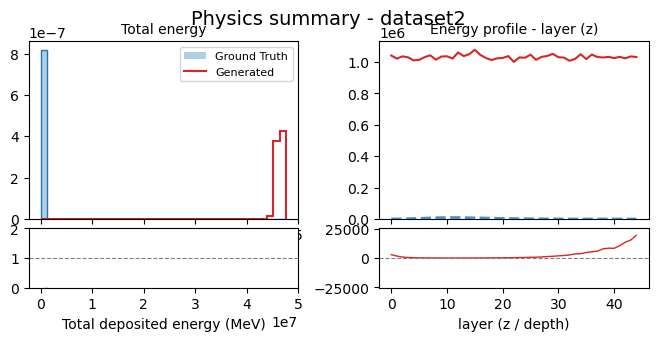

In [77]:
fig = plt.figure(figsize=(8, 3.2))
gs = fig.add_gridspec(1, 2, wspace=0.3)

# Panel 1: total energy
inner1 = gs[0, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax1_main = fig.add_subplot(inner1[0])
ax1_ratio = fig.add_subplot(inner1[1], sharex=ax1_main)
_draw_hist_panel(ax1_main, ax1_ratio, real_E_tot, gen_E_tot)
ax1_main.set_title("Total energy", fontsize=10)
ax1_ratio.set_xlabel("Total deposited energy (MeV)")

# Panel 2: energy profile layer (z)
inner2 = gs[0, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax2_main = fig.add_subplot(inner2[0])
ax2_ratio = fig.add_subplot(inner2[1], sharex=ax2_main)
_draw_profile_panel(ax2_main, ax2_ratio, real_energy_layer, gen_energy_layer)
ax2_main.set_title("Energy profile - layer (z)", fontsize=10)
ax2_ratio.set_xlabel("layer (z / depth)")

ax1_main.legend(fontsize=8)
fig.suptitle(f"Physics summary - {CONFIG_NAME}", fontsize=8)
plt.tight_layout()
plt.show()

## References

- X.T. Nguyen et al., “Differentiable Surrogate for Detector Simulation and Design with Diffusion Models,” MLST 7, 025061 (2026). arXiv:2601.07859.

- W. Peebles et al., “Scalable Diffusion Models with Transformers,” arXiv:2212.09748 (2022).

- J. Ho et al., “Denoising Diffusion Probabilistic Models,” NeurIPS 33, 6840-6851 (2020). arXiv:2006.11239.

- J. Song et al., “Denoising Diffusion Implicit Models,” ICLR 2021, (2021). arXiv:2010.02502.